In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/266.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/071.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/344.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/228.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/099.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/130.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/158.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/003.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/253.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/014.jpeg
/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset/cancer/381.jpeg
/kaggle/input/datasets/gautiigiri/oral-data

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.utils import class_weight

2026-04-16 16:20:22.869557: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776356423.062763      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776356423.115303      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776356423.536150      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776356423.536189      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776356423.536192      23 computation_placer.cc:177] computation placer alr

In [3]:
# ===== CONFIG =====
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30

DATASET_DIR = "/kaggle/input/datasets/gautiigiri/oral-data-for-mobilenet/oral_dataset"

# ===== LOAD DATA =====
filepaths = []
labels = []

class_map = {"normal": 0, "cancer": 1}

for class_name in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    for img in os.listdir(class_path):
        filepaths.append(os.path.join(class_path, img))
        labels.append(class_map[class_name])

filepaths = np.array(filepaths)
labels = np.array(labels)

print("Total images:", len(filepaths))

# ===== CLASS WEIGHTS =====
class_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Total images: 950
Class Weights: {0: np.float64(1.0555555555555556), 1: np.float64(0.95)}


In [4]:
# ===== AUGMENTATION =====
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2   # 80/20 split
)

train_gen = datagen.flow_from_dataframe(
    pd.DataFrame({"filename": filepaths, "class": labels}),
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="training"
)

val_gen = datagen.flow_from_dataframe(
    pd.DataFrame({"filename": filepaths, "class": labels}),
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    subset="validation"
)

Found 760 validated image filenames.
Found 190 validated image filenames.


In [5]:
# ===== MODEL =====
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Phase 1: Freeze
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# ===== PHASE 1 TRAIN =====
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
)

# ===== PHASE 2 (FINE-TUNE) =====
for layer in base_model.layers[-8:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ModelCheckpoint("/kaggle/working/final_vgg16.keras", save_best_only=True)
    ]
)

I0000 00:00:1776356448.078235      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1776356452.787201      66 service.cc:152] XLA service 0x7cb82000cea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776356452.787235      66 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776356453.312139      66 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/48 ━━━━━━━━━━━━━━━━━━━━ 6:06 8s/step - accuracy: 0.3750 - loss: 0.8620

I0000 00:00:1776356458.641750      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 4/48 ━━━━━━━━━━━━━━━━━━━━ 16s 374ms/step - accuracy: 0.4076 - loss: 0.8479

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 36s 610ms/step - accuracy: 0.4948 - loss: 0.7530 - val_accuracy: 0.0000e+00 - val_loss: 0.9692
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 344ms/step - accuracy: 0.5922 - loss: 0.6739 - val_accuracy: 0.0211 - val_loss: 0.8510
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 347ms/step - accuracy: 0.6342 - loss: 0.6409 - val_accuracy: 0.0632 - val_loss: 0.8710
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 347ms/step - accuracy: 0.6243 - loss: 0.6397 - val_accuracy: 0.2053 - val_loss: 0.8277
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 349ms/step - accuracy: 0.7076 - loss: 0.5870 - val_accuracy: 0.3316 - val_loss: 0.7824
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 16s 335ms/step - accuracy: 0.6791 - loss: 0.5816 - val_accuracy: 0.3000 - val_loss: 0.8210
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 17s 349ms/step - accuracy: 0.6896 - loss: 0.5782 - val_accuracy: 0.6316 - val_loss: 0.6648
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 621ms/step - accuracy: 0.7552 - loss: 0.5303 - val_accuracy: 0

Model saved successfully!


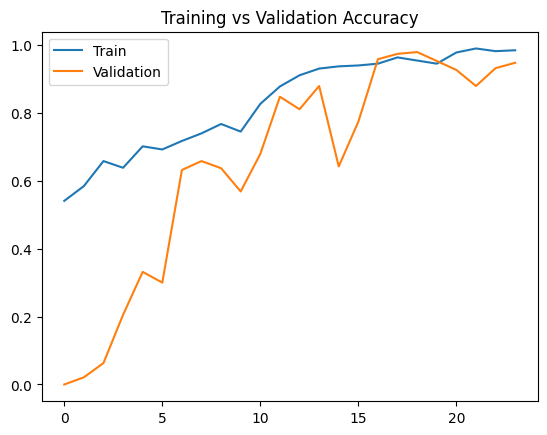

In [6]:
model.save("/kaggle/working/final_vgg16_full.keras")

print("Model saved successfully!")

# ===== OPTIONAL PLOT =====
plt.plot(history1.history['accuracy'] + history2.history['accuracy'], label='Train')
plt.plot(history1.history['val_accuracy'] + history2.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [7]:
import tensorflow as tf

# Load saved model
model = tf.keras.models.load_model("/kaggle/working/final_vgg16_full.keras")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# Save TFLite model
with open("/kaggle/working/model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved!")

INFO:tensorflow:Assets written to: /tmp/tmp35kh0dgv/assets


INFO:tensorflow:Assets written to: /tmp/tmp35kh0dgv/assets


Saved artifact at '/tmp/tmp35kh0dgv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137133542229392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137130392051664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137130392052624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137130392050128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137130392052816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137130392051088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137130392053200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137130392053008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137130392053584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137130392053392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137130392053968

W0000 00:00:1776356902.082531      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776356902.082561      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1776356902.097453      23 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


In [8]:
import os
print(os.listdir("/kaggle/working"))

['model.tflite', 'final_vgg16.keras', '__notebook__.ipynb', 'final_vgg16_full.keras']
